Epoch 1/50


c:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6898 - loss: 0.8471 - val_accuracy: 0.8929 - val_loss: 0.5050
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9347 - loss: 0.3175 - val_accuracy: 0.9643 - val_loss: 0.1689
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9673 - loss: 0.1094 - val_accuracy: 1.0000 - val_loss: 0.0442
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0534 - val_accuracy: 1.0000 - val_loss: 0.0233
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9837 - loss: 0.0348 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9959 - loss: 0.0280 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9837 - loss: 0.0292 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9918 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0089
Epo

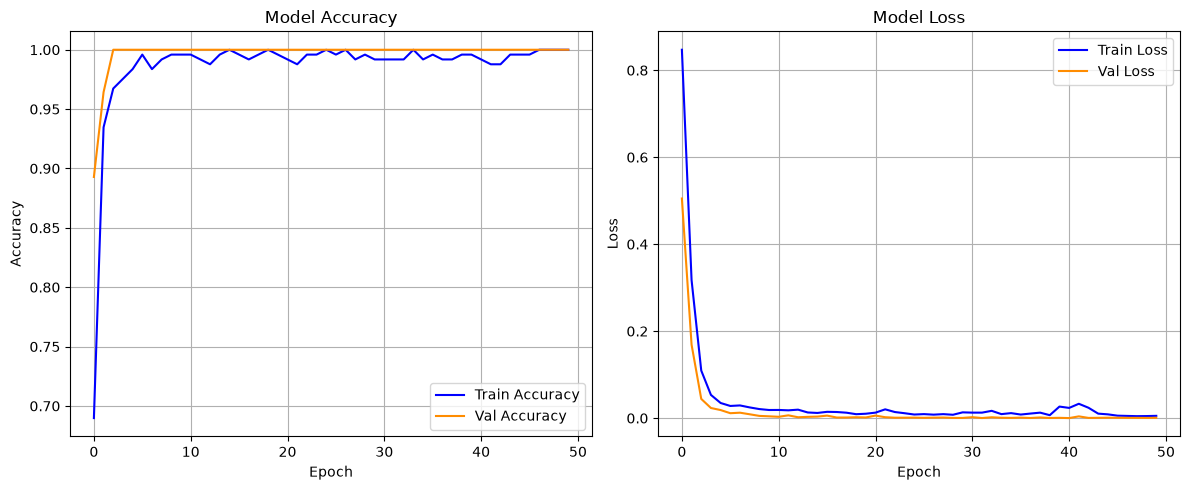

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# 1. โหลดข้อมูล
csv_path = 'penguins_lter.csv'
df = pd.read_csv(csv_path)

# เลือก 4 Features หลักและ Target
features = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)',
]
target = 'Species'

# ตัดแถวที่มีค่าว่าง (NaN)
data = df[features + [target]].dropna()
X = data[features].values
y = data[target].values

# 2. แปลงชื่อสายพันธุ์ให้เป็นตัวเลข (0, 1, 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 3. แบ่งชุดข้อมูล Train 80% และ Test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. Standardize ข้อมูล (ปรับสเกล)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. สร้างโมเดล Neural Network
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax'),
])

# 6. กำหนด Optimizer และ Loss Function
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# 7. เทรนโมเดล (Training)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1,
)

# 8. ประเมินผลบน Test Set
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\n' + '=' * 40)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')
print('=' * 40)

# 9. วาดกราฟผลการเทรน (Accuracy & Loss)
plt.figure(figsize=(12, 5))

# กราฟ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(
    history.history['val_accuracy'], label='Val Accuracy', color='darkorange'
)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# กราฟ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='darkorange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()